# Khám phá Dữ Liệu (Exploratory Data Analysis)

Notebook này phục vụ cho Task DE-4 trong Sprint 2. Mục đích:
1. Load và hiển thị các số liệu cơ bản từ `metadata.json`.
2. Thống kê phân bố số lượng ảnh trên mỗi video.
3. Trực quan hoá tỷ lệ Train / Test split.
4. Hiển thị mẫu một vài ảnh kèm caption (title của video).

In [1]:
import os
import sys
import json
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

# Thêm đường dẫn project vào sys.path để import src
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

from src.data.metadata_store import load_metadata

# Cấu hình thư mục
metadata_path = os.path.join(project_root, "data", "metadata.json")
print(f"Đang đọc dữ liệu từ: {metadata_path}")

Đang đọc dữ liệu từ: /Users/thinhnguyen/Desktop/conquer/Vision-Retrieval-Project/data/metadata.json


In [2]:
# 1. Đọc dữ liệu
if not os.path.exists(metadata_path):
    print("Lỗi: Không tìm thấy file metadata.json. Hãy chạy prepare_dataset.py trước.")
else:
    records = load_metadata(metadata_path)
    print(f"Tổng số lượng ảnh (frames): {len(records)}")
    
    labels = [r.label for r in records]
    unique_labels = set(labels)
    print(f"Tổng số video (labels): {len(unique_labels)}")

Tổng số lượng ảnh (frames): 7915
Tổng số video (labels): 96


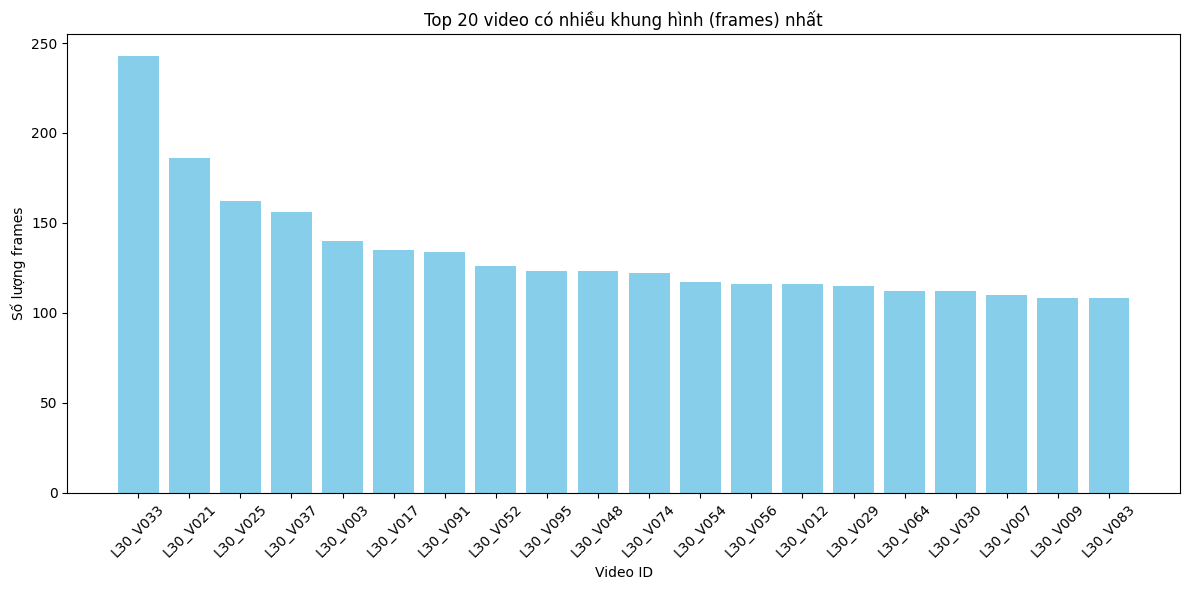

In [3]:
# 2. Vẽ biểu đồ phân bố frames / video
if 'records' in locals():
    label_counts = Counter(labels)
    # Lấy top 20 video có nhiều frame nhất để dễ nhìn
    top_labels = label_counts.most_common(20)
    
    vid_names = [x[0] for x in top_labels]
    vid_counts = [x[1] for x in top_labels]
    
    plt.figure(figsize=(12, 6))
    plt.bar(vid_names, vid_counts, color='skyblue')
    plt.title('Top 20 video có nhiều khung hình (frames) nhất')
    plt.xlabel('Video ID')
    plt.ylabel('Số lượng frames')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

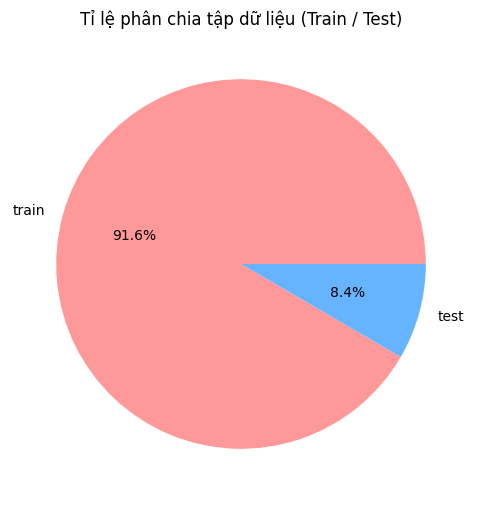

In [4]:
# 3. Biểu đồ tròn Train / Test Split
if 'records' in locals():
    splits = [r.split for r in records if r.split is not None]
    if not splits:
        print("Cảnh báo: Dữ liệu chưa được chia Train/Test. Vui lòng gọi hàm split_dataset().")
    else:
        split_counts = Counter(splits)
        plt.figure(figsize=(6, 6))
        plt.pie(split_counts.values(), labels=split_counts.keys(), autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
        plt.title('Tỉ lệ phân chia tập dữ liệu (Train / Test)')
        plt.show()

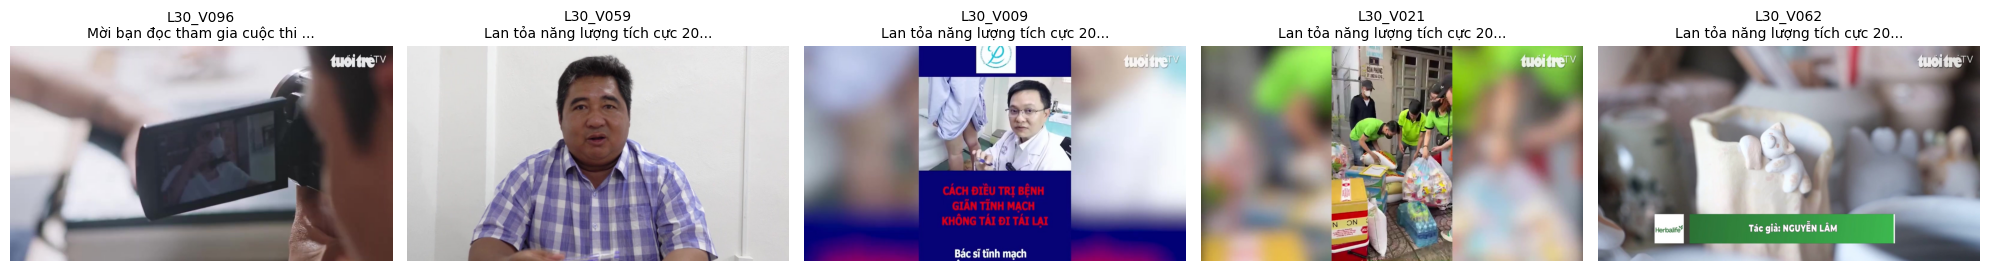

In [5]:
# 4. Hiển thị một số ảnh mẫu
import random
if 'records' in locals() and len(records) > 0:
    sample_records = random.sample(records, min(5, len(records)))
    
    fig, axes = plt.subplots(1, len(sample_records), figsize=(20, 5))
    for i, r in enumerate(sample_records):
        try:
            img = Image.open(r.path)
            axes[i].imshow(img)
            axes[i].axis('off')
            
            # Rút gọn caption nếu quá dài
            cap = r.caption or r.label
            if len(cap) > 30:
                cap = cap[:30] + "..."
            axes[i].set_title(f"{r.label}\n{cap}", fontsize=10)
        except Exception as e:
            axes[i].set_title("Lỗi hiển thị")
            axes[i].axis('off')
            
    plt.tight_layout()
    plt.show()